# Teleop recording stats

Quick analysis of a `TeleopRecorder` SQLite recording — rate / jitter, pose trajectory, engagement windows.

Recording schema: `right_controller_output` (PoseStamped) + `buttons` (Buttons). Edit `RECORDING_PATH` below.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from dimos.memory2.store.sqlite import SqliteStore

RECORDING_PATH = Path("../../../recording_teleop.db")

store = SqliteStore(path=str(RECORDING_PATH))
obs = {name: stream.to_list() for name, stream in store.streams.items()}

print(f"recording: {RECORDING_PATH.name}")
for name, items in obs.items():
    print(f"  {store.streams[name].summary()}")

recording: recording_teleop.db
  Stream("buttons"): 6396 items, 2026-05-07 18:30:10 — 2026-05-07 18:32:20 (130.4s)
  Stream("right_controller_output"): 666 items, 2026-05-07 18:31:46 — 2026-05-07 18:32:02 (15.7s)


## Trace IDs & end-to-end latency

Every `Joy` / `PoseStamped` / `JointState` now carries a `trace_id` in its LCM `Header.seq`. Origin is `QuestTeleopModule._on_pose_bytes` (assigns at system entry); downstream stages forward the same id. Once you record more than one stage, you join by `obs.data.trace_id` to get exact per-message E2E latency without nearest-neighbor matching.

For now this recording only has `right_controller_output`, so we just show that trace_ids are populated, increasing, and unique.

In [ ]:
pose = obs.get("right_controller_output", [])
if not pose:
    print("no pose stream")
else:
    tids = np.array([o.data.trace_id for o in pose], dtype=np.int64)
    untagged = (tids == 0).sum()
    unique = len(np.unique(tids[tids != 0]))
    monotonic = np.all(np.diff(tids[tids != 0]) >= 0)
    print(
        f"pose msgs: {len(tids)}   untagged (trace_id=0): {untagged}   unique tagged: {unique}   monotonic: {monotonic}"
    )
    if untagged == len(tids):
        print("  → recording predates trace_id support; re-record to enable.")
    elif untagged:
        print("  → some msgs untagged; producer may be older. Drop them when joining.")
    else:
        print(
            f"  → trace_id range: [{tids.min()}, {tids.max()}], gap count: {(np.diff(tids[tids != 0]) > 1).sum()}"
        )

# When you record a second stage (e.g., joint_state), join like this:
#
#   pose_by_id = {o.data.trace_id: o for o in obs['right_controller_output']}
#   pairs = [(pose_by_id[js.data.trace_id], js) for js in obs['joint_state']
#            if js.data.trace_id and js.data.trace_id in pose_by_id]
#   lat_ms = np.array([(js.data.ts - p.data.ts) * 1000 for p, js in pairs])
#   print(f'E2E p50={np.median(lat_ms):.1f}  p95={np.percentile(lat_ms, 95):.1f}  p99={np.percentile(lat_ms, 99):.1f} ms')

## Rate / jitter

Inter-message intervals per stream. Tight distribution = stable rate; long tail = stalls.

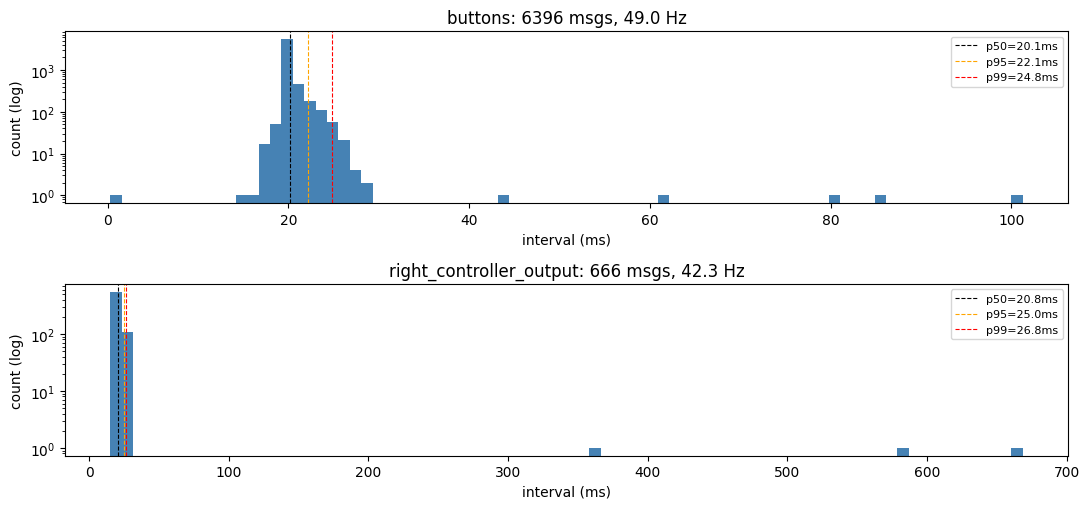

In [2]:
fig, axes = plt.subplots(len(obs), 1, figsize=(11, 2.6 * len(obs)), squeeze=False)
for ax, (name, items) in zip(axes[:, 0], obs.items(), strict=False):
    if len(items) < 2:
        ax.set_title(f"{name} (n<2)")
        continue
    ts = np.sort(np.array([o.ts for o in items]))
    intervals = np.diff(ts) * 1000.0
    p50, p95, p99 = np.percentile(intervals, [50, 95, 99])
    rate = len(ts) / (ts[-1] - ts[0])
    ax.hist(intervals, bins=80, log=True, color="steelblue", edgecolor="none")
    for p, c, lbl in [(p50, "black", "p50"), (p95, "orange", "p95"), (p99, "red", "p99")]:
        ax.axvline(p, color=c, linestyle="--", lw=0.8, label=f"{lbl}={p:.1f}ms")
    ax.set_title(f"{name}: {len(ts)} msgs, {rate:.1f} Hz")
    ax.set_xlabel("interval (ms)")
    ax.set_ylabel("count (log)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Pose trajectory

Position (x/y/z) and orientation (rpy) of the right controller over time.

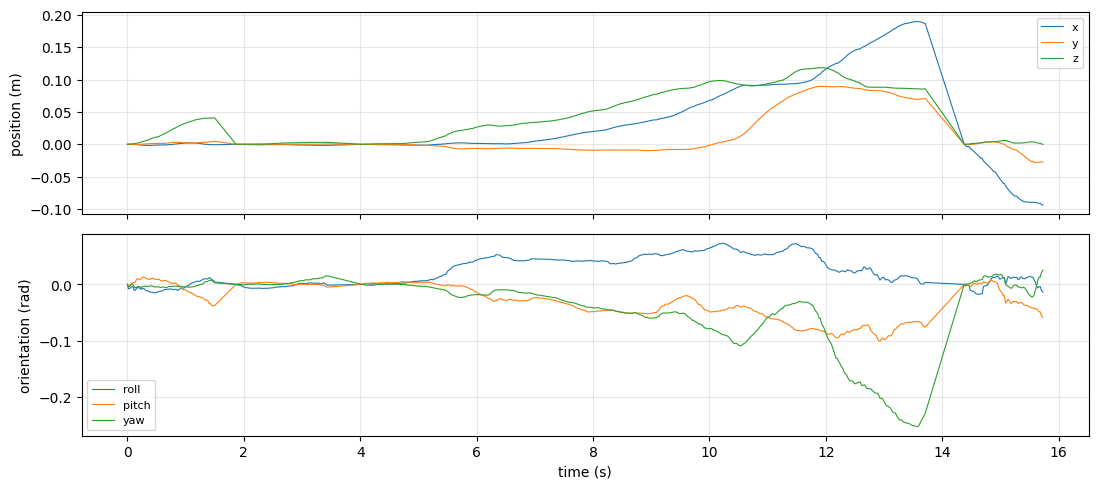

position range: x=0.283m  y=0.118m  z=0.118m


In [3]:
pose = obs.get("right_controller_output", [])
if not pose:
    print("no right_controller_output stream")
else:
    ts = np.array([o.ts for o in pose])
    rel = ts - ts[0]
    xyz = np.array([[o.data.x, o.data.y, o.data.z] for o in pose])
    rpy = np.array([[o.data.roll, o.data.pitch, o.data.yaw] for o in pose])

    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    for i, lbl in enumerate("xyz"):
        axes[0].plot(rel, xyz[:, i], lw=0.8, label=lbl)
    axes[0].set_ylabel("position (m)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    for i, lbl in enumerate(["roll", "pitch", "yaw"]):
        axes[1].plot(rel, rpy[:, i], lw=0.8, label=lbl)
    axes[1].set_ylabel("orientation (rad)")
    axes[1].set_xlabel("time (s)")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    rng = np.ptp(xyz, axis=0)
    print(f"position range: x={rng[0]:.3f}m  y={rng[1]:.3f}m  z={rng[2]:.3f}m")

## Engagement windows

Buttons are bit-packed; non-zero = something held. Adjacent non-zero samples (gap < 200 ms) get stitched into intervals = active teleop periods.

4 engagement events, total held: 14.12s
  [0]  96.15s ->  97.65s  (1.50s)
  [1]  98.02s ->  99.60s  (1.58s)
  [2] 100.18s -> 109.86s  (9.69s)
  [3] 110.53s -> 111.88s  (1.35s)


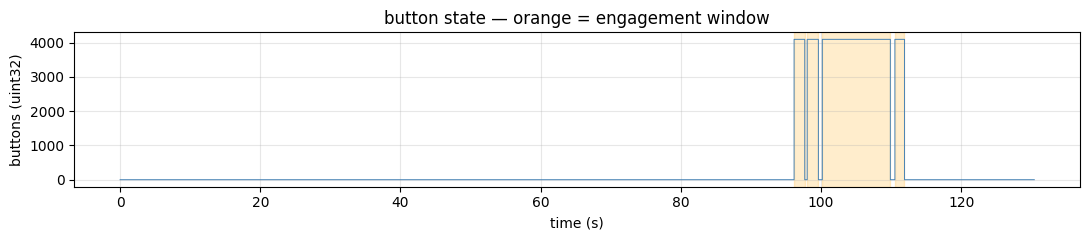

In [4]:
btn = obs.get("buttons", [])
if not btn:
    print("no buttons stream")
else:
    t0 = btn[0].ts
    held = store.streams["buttons"].filter(lambda o: o.data.data != 0).to_list()
    if not held:
        print("no engagement events (no non-zero button samples)")
    else:
        held_ts = np.array([o.ts for o in held])
        breaks = np.where(np.diff(held_ts) > 0.2)[0]
        starts = np.concatenate([[held_ts[0]], held_ts[breaks + 1]]) - t0
        ends = np.concatenate([held_ts[breaks], [held_ts[-1]]]) - t0
        durations = ends - starts
        print(f"{len(starts)} engagement events, total held: {durations.sum():.2f}s")
        for i, (s, e, d) in enumerate(zip(starts, ends, durations, strict=False)):
            print(f"  [{i}] {s:6.2f}s -> {e:6.2f}s  ({d:.2f}s)")

        fig, ax = plt.subplots(figsize=(11, 2.5))
        raw = np.array([o.data.data for o in btn], dtype=np.uint32)
        rel = np.array([o.ts for o in btn]) - t0
        ax.step(rel, raw, where="post", lw=0.7, color="steelblue")
        for s, e in zip(starts, ends, strict=False):
            ax.axvspan(s, e, color="orange", alpha=0.2)
        ax.set_xlabel("time (s)")
        ax.set_ylabel("buttons (uint32)")
        ax.set_title("button state — orange = engagement window")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()